In [163]:
%pip install torch==2.6.0
%pip install torchvision==0.21.0
%pip install numpy
%pip install matplotlib
%pip install tdqm
%pip install numpy==1.24.1

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.24.1.tar.gz (10.9 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "c:\Users\wthom\Documents\GitHub\CSE_144_Final_Project\.venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "c:\Users\wthom\Documents\GitHub\CSE_144_Final_Project\.venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\wthom\Documents\GitHub\CSE_144_Final_Project\.venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 137, in get_requires_for_build_wheel
          backend = _build_backend()
                    ^^^^^^^^^^^^^^^^
        File "c:\Users\wthom\Documents\GitHub\CSE_144_Final_

In [246]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import trange
import os
from tqdm import tqdm
import pathlib
from torchvision.io import decode_image
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
from torchvision.transforms import v2
from torch.utils.data import Dataset, Subset
import torchvision.models as models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Use hardware acceleration if availaible

In [247]:
# https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

cuda


### Utility Function: Gets path to model file

In [248]:
# Get path to model, if it exists
def getModelPath() -> str:
    path: pathlib.Path = pathlib.Path().resolve()
    dir_list: list[str] = os.listdir(path)
    
    if 'model' in dir_list:
        model_dir_path = os.path.join(path,'model')
    else:
        raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

    # model_path_list = os.listdir(model_dir_path)
    timestr = time.strftime("%Y%m%d_%H%M%S")
    model_file_name = os.path.join(model_dir_path,timestr) + ".pth"

    return model_file_name

### Utility Function: Gets path to weights file

In [249]:
# Get path to weights, if it exists
def getWeightsPath() -> str:
    path: pathlib.Path = pathlib.Path().resolve()
    dir_list: list[str] = os.listdir(path)
    
    if 'weights' in dir_list:
        weights_dir_path = os.path.join(path,'weights')
    else:
        raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

    # model_path_list = os.listdir(model_dir_path)
    timestr = time.strftime("%Y%m%d_%H%M%S")
    model_file_name = os.path.join(weights_dir_path,timestr) + ".pth"

    return model_file_name

# How to read the data
* Reading the data
* Putting the image stright into ram is not a good idea
* I think maybe I will be using a CVS file that store the classification of the image and the path to the image. 

In [250]:
# https://www.geeksforgeeks.org/python-list-files-in-a-directory/
# https://stackoverflow.com/questions/3430372/how-do-i-get-the-full-path-of-the-current-files-directory
# https://stackoverflow.com/questions/431684/how-do-i-change-the-working-directory-in-python
path = pathlib.Path().resolve()
dir_list = os.listdir(path)
if 'train' in dir_list:
    train_dir_path = os.path.join(os.path.join(path,'train'),'train')
else:
    raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"" + os.path.join(path,'train') + "\"")

# Setting up transform for the image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data
* https://pytorch.org/vision/0.9/transforms.html

In [251]:
# transform = transforms.Compose()
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224,244)),
    transforms.ToTensor(),
])

# Import image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data

In [252]:

dataset = datasets.ImageFolder(train_dir_path,transform=transform)

# Split dataset
* https://discuss.pytorch.org/t/how-to-split-dataset-into-test-and-validation-sets/33987

In [253]:
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.9,0.1])

In [254]:
# all_labels = []
# for _, labels in test_dataset:
#     all_labels.append(labels)

# print(list(set(all_labels)))
# print(len(list(set(all_labels))))
# for item in set(all_labels):
#     print(f"Frequency of {item}: {all_labels.count(item)}")

# Data loaders

In [255]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Image augmentation
* Adversarial attack (Suggested by Johnson)
* Flip
* Inverse
* Rotate
* Zoom

### Resourse on doing augmentation
* https://pytorch.org/vision/main/transforms.html

# Image augmentation function
* https://pytorch.org/vision/main/transforms.html

In [256]:
AUGMENTATIONS: list[v2.Transform] = [
    v2.GaussianNoise(),
    v2.RandomSolarize(threshold=0.1),
    v2.ColorJitter(),
    v2.RandomRotation(degrees=90),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomInvert(),
    # v2.RandomCrop(size=(224,224))
]

NUM_AUGMENTATIONS: int = 4

In [257]:
# TODO make the random number determinstic via a seed
def getRandomAugments() -> list[v2.Transform]:
    augs: list[v2.Transform] = []
    for _ in range(NUM_AUGMENTATIONS):
        rand: int = round(random.random() * len(AUGMENTATIONS))
        augs.append(AUGMENTATIONS[rand - 1])
    
    return augs

getRandomAugments()

[RandomRotation(degrees=[-90.0, 90.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0),
 RandomInvert(p=0.5),
 RandomSolarize(p=0.5, threshold=0.1),
 RandomSolarize(p=0.5, threshold=0.1)]

In [258]:
AUGMENTATIONS2: list[v2.Transform] = [
    v2.GaussianNoise(),
    v2.RandomSolarize(threshold=0.1),
    v2.ColorJitter(),
    v2.RandomRotation(degrees=90),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomInvert(),
    v2.RandomCrop(size=(224,224)),
    v2.RandomChannelPermutation(),
    # v2.Grayscale(),
    v2.RandomAutocontrast(),
    v2.RandomEqualize(),
]
RANDOM_NUM_AUGMENTATIONS: int = 10

In [259]:
def randomTransform():
    transform_list = []
    for _ in range(random.randint(1,RANDOM_NUM_AUGMENTATIONS)):
        transform_list.append(v2.RandomChoice(AUGMENTATIONS2))
    transform_list.append(v2.Resize((224,244)))
    return v2.Compose(transform_list)

In [260]:
# Horizontally flip each image at the given probability
def augment_images(images: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    augmented_images: list[torch.Tensor] = []
    augmented_labels: list[torch.Tensor] = []
    transforms2: v2.Transform = randomTransform()
    for image, label in zip(images, labels):
        augments: list[v2.Transform] = getRandomAugments()
        random_value = random.random() # random number in range [0.0,1.0)
        if random_value <= 0.8:
            augments.insert(0,v2.RandomResizedCrop(size=(224, 224), antialias=True))
        for i in range(NUM_AUGMENTATIONS):
            transforms: v2.Transform = v2.Compose([
                # v2.RandomResizedCrop(size=(224, 224), antialias=True),
                augments[i],
                # v2.Normalize(mean=[0.5], std=[0.5])  # Normalize as before
                v2.Resize((224,244)),
            ])
            if random_value <= 0.3:
                image: torch.Tensor = transforms2(image)
            img: torch.Tensor = transforms(image)
            augmented_images.append(img)
            augmented_labels.append(label)
        

    # print(np.array(augmented_images))
    return torch.from_numpy(np.array(augmented_images)), torch.from_numpy(np.array(augmented_labels))

In [261]:
print(test_dataset.dataset, test_dataset.indices)

Dataset ImageFolder
    Number of datapoints: 1000
    Root location: C:\Users\wthom\Documents\GitHub\CSE_144_Final_Project\Final_Project\train\train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 244), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           ) [256, 526, 70, 461, 454, 634, 393, 794, 520, 156, 966, 675, 598, 462, 13, 90, 875, 55, 45, 643, 630, 753, 572, 19, 61, 104, 581, 602, 754, 665, 105, 435, 662, 559, 14, 863, 539, 519, 761, 232, 554, 441, 574, 747, 653, 877, 224, 293, 556, 358, 898, 806, 712, 254, 97, 710, 736, 621, 146, 465, 431, 330, 395, 129, 741, 579, 115, 111, 549, 80, 222, 617, 969, 809, 527, 776, 151, 822, 870, 240, 277, 7, 918, 466, 400, 557, 566, 846, 985, 481, 219, 318, 894, 2, 770, 335, 284, 638, 96, 455]


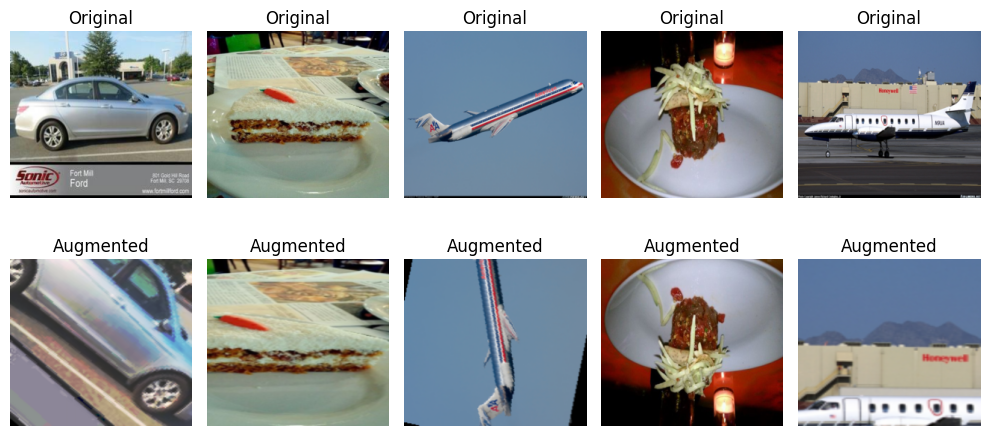

In [262]:
# Visualize some original and augmented images
plt.figure(figsize=(10, 5))
# Get a batch of images from the test dataset
images, labels = next(iter(test_loader))
augmented_batch, augmented_labels = augment_images(images[:5],labels[:5])  # Get 5 images and their augmentations

# Plot original and augmented images
for i in range(5):
    # Original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].permute(1, 2, 0).cpu())  # Convert from CxHxW to HxWxC
    plt.title("Original")
    plt.axis("off")

    # Augmented image
    plt.subplot(2, 5, i + 6)  # i + 1 + 5
    plt.imshow(augmented_batch[i*4].permute(1, 2, 0).cpu())
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Learning transfer learning from exercise
* https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs?usp=sharing

In [263]:
# Define custom classification head
class RegNetHead(nn.Module):
    def __init__(self, in_features=3712, num_classes=100):  # Adjust `in_features` to match RegNet output
        super(RegNetHead, self).__init__()
         # self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            # nn.Linear(in_features, 1000),
            # nn.ReLU(),
            nn.Linear(in_features, 1000),
            nn.Linear(1000, num_classes),
            # nn.Softmax()  # Ensure softmax is applied along the correct dimension
        )

    def forward(self, x):
        # x = self.avgpool(x)
        return self.classifier(x)

# Load pretrained RegNet model
base_model = models.regnet_y_32gf(weights=models.RegNet_Y_32GF_Weights.IMAGENET1K_V2).to(device)

# Remove the original classifier (fc layer) and add our custom head
in_features = base_model.fc.in_features  # Get input features of last linear layer
base_model.fc = RegNetHead(in_features, num_classes=100).to(device)  # Replace with custom head

# Verify Model Architecture
print(base_model)

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 232, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(232, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 232, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(232, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(232, 232, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
            (1):

In [264]:
# Freeze all layers first
for param in base_model.parameters():
    param.requires_grad = False

# Unfreeze the last convolutional block (block4 in RegNet)
# for param in base_model.trunk_output[3].parameters():  # Block 4 in trunk_output
#     param.requires_grad = True

# Unfreeze the classification head (fc layer)
for param in base_model.fc.parameters():
    param.requires_grad = True

for name, param in base_model.named_parameters():
    if param.requires_grad:
        print(f"Trainable: {name}")

# Verify trainable parameters
trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in base_model.parameters())
print(f"Trainable Parameters: {trainable_params}/{total_params}")

Trainable: fc.classifier.0.weight
Trainable: fc.classifier.0.bias
Trainable: fc.classifier.1.weight
Trainable: fc.classifier.1.bias
Trainable Parameters: 3813100/145146870


# Setting up the nn
* This code is from https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs#scrollTo=3kTYygi258Yv
* https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html#torch.optim.lr_scheduler.ReduceLROnPlateau

In [265]:
SHOULD_LOAD_MODEL_FROM_DISK = False

# Initialize the network and optimizer
# base_model = models.vgg16(pretrained=True).to(device=device)
net = RegNetHead().to(device=device)

if SHOULD_LOAD_MODEL_FROM_DISK:
    net.load_state_dict(torch.load(getModelPath(), weights_only=True))
    net.eval()

# optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Accuracy calculation
* https://pytorch.org/docs/stable/generated/torch.nn.functional.one_hot.html

In [266]:
# Function to calculate accuracy
def accuracy(loader, model, base_model):
    model.eval()  # Put model in eval model so no weight updates
    correct = 0
    total = 0
    loss = 0
    with torch.no_grad():
        for data in loader:
            image, label = data
            image, label = image.to(device=device), label.to(device=device)
            with torch.no_grad():
              # The REG is frozen
            #   reg_features = base_model(image)
              output = base_model(image)
            # output = net(reg_features)
            _, predicted = torch.max(output.data, 1)

            # label = F.one_hot(torch.from_numpy(np.array(label)), num_classes=100)
            # print(label)
            # print(output)
            loss += criterion(output, label)
            loss.cpu()
            
            total += label.size(0)
            correct += (predicted == label).sum().item()
    return loss, correct / total

def MyhillNerode(*args):
    return accuracy(*args)

# L1/L2 Regularization
* https://www.geeksforgeeks.org/l1l2-regularization-in-pytorch/

In [267]:
REGULARIZATION_LAMDA = 0.1
REGULARIZATION_MODE = 2

In [268]:
def regularization(model,mode):
    if(mode == 1):
        return sum(p.abs().sum() for p in model.parameters())
    elif(mode == 2):
        return sum(p.pow(2).sum() for p in model.parameters())
    else:
        return 0

# Training

In [269]:
# indice = random.sample(train_dataset.indices,batch_size)
# indice = torch.tensor(indice)
# try1 = dataset[indice]

In [270]:
import torch.utils
import torch.utils.data


class BaileyNetwork:
    def __init__(self, model, optimizer, base_model):
        self.model = model
        self.optimizer = optimizer
        self.base_model = base_model

    def train(self, dataset: Dataset, train_dataset: Subset, test_loader: DataLoader, epochs=10, batch_size=10):

        self.model.train()

        losses_train, losses_val = [], []
        accs_val = []

        num_batches = (len(train_dataset) + batch_size - 1) // batch_size

        for epoch_id in tqdm(range(epochs)):
            epoch_loss = 0

            indices = train_dataset.indices
            np.random.shuffle(indices)

            # Create a subset from dataset using the shuffled indices
            my_subset = torch.utils.data.Subset(dataset, indices)

            subset_loader = DataLoader(my_subset, batch_size=len(my_subset))
            train_set = next(iter(subset_loader))

            x_train, y_train = train_set[0], train_set[1]

            train_correct = 0

            # train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

            # Get the batch data 
            for batch in range(num_batches):
            # for i, data in enumerate(train_loader, 0):
            #     x_batch, y_batch = data

                start_index = batch * batch_size
                # print(x_train)
                end_index = min(start_index + batch_size, len(x_train))

                x_batch = x_train[start_index: end_index]
                y_batch = y_train[start_index: end_index]


                # Apply augmentation and normalization 


                x_batch, y_batch = augment_images(x_batch, y_batch)    

                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                # x_batch = normalize_images(x_batch)

                # ===========================
                # Setting up to run the model
                # ===========================

                self.optimizer.zero_grad()      # Reset grad to zero
                
                # with torch.no_grad():       # Disabling gradient calculation 
                #     regular_expression_net = self.base_model(x_batch.to(device=device))   # Running RegNet
                
                # outputs = self.model(regular_expression_net)    # Running our model using the output from the RegNet

                outputs = self.base_model(x_batch)                 # Running our model
                # outputs = net(regular_expression_net)
                
                loss = criterion(outputs, y_batch)          # Calculating the loss
                
                loss += REGULARIZATION_LAMDA * regularization(self.model,REGULARIZATION_MODE) 

                loss.backward()                                  # Back propagation 
                #for name, param in self.base_model.named_parameters():

                # Update parameters using the optimizer 
                self.optimizer.step()                                 # Update parameters

                _, predicted = torch.max(outputs.data, 1)
                train_correct += (predicted == y_batch).sum().item()

                epoch_loss += loss.item()

            # Print epoch statistics
            loss_train = epoch_loss / num_batches
            # loss_val, acc_val = self.evaluate(x_val, y_val)
            loss_val, acc_val = MyhillNerode(test_loader, self.model, self.base_model)
            acc_train = train_correct / (len(x_train) * NUM_AUGMENTATIONS)
            losses_train.append(loss_train)
            losses_val.append(loss_val)
            accs_val.append(acc_val)
            tqdm.write(f"Epoch {epoch_id + 1}/{epochs}, Training Loss: {loss:.4f}, Training ACC: {acc_train:.4f}, Validation Loss: {loss_val:.4f}, Validation ACC: {acc_val:.4f}")

        return losses_train, losses_val, accs_val

# Training

#### Hyperparameters

In [271]:
EPOCHS: int = 50
BATCHES: int = 10
LEARNING_RATE: float = 0.01

In [272]:
optimizer = torch.optim.SGD(base_model.parameters(), lr=LEARNING_RATE, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

trainer = BaileyNetwork(model=net, optimizer=optimizer, base_model=base_model)

In [273]:
losses_train, losses_val, accs_val = trainer.train(dataset, train_dataset, test_loader, epochs=EPOCHS, batch_size=BATCHES)

  2%|▏         | 1/50 [00:41<33:46, 41.35s/it]

Epoch 1/50, Training Loss: 40.2396, Training ACC: 0.0461, Validation Loss: 3.8134, Validation ACC: 0.0500


  4%|▍         | 2/50 [01:23<33:28, 41.84s/it]

Epoch 2/50, Training Loss: 40.2503, Training ACC: 0.1194, Validation Loss: 3.3748, Validation ACC: 0.1100


  6%|▌         | 3/50 [02:04<32:23, 41.35s/it]

...

Epoch 48/50, Training Loss: 37.3449, Training ACC: 0.7831, Validation Loss: 2.1004, Validation ACC: 0.4500


 98%|█████████▊| 49/50 [33:49<00:41, 41.58s/it]

Epoch 49/50, Training Loss: 37.2915, Training ACC: 0.7886, Validation Loss: 2.0528, Validation ACC: 0.4700


100%|██████████| 50/50 [34:30<00:00, 41.41s/it]

Epoch 50/50, Training Loss: 36.7945, Training ACC: 0.7981, Validation Loss: 2.1871, Validation ACC: 0.4500


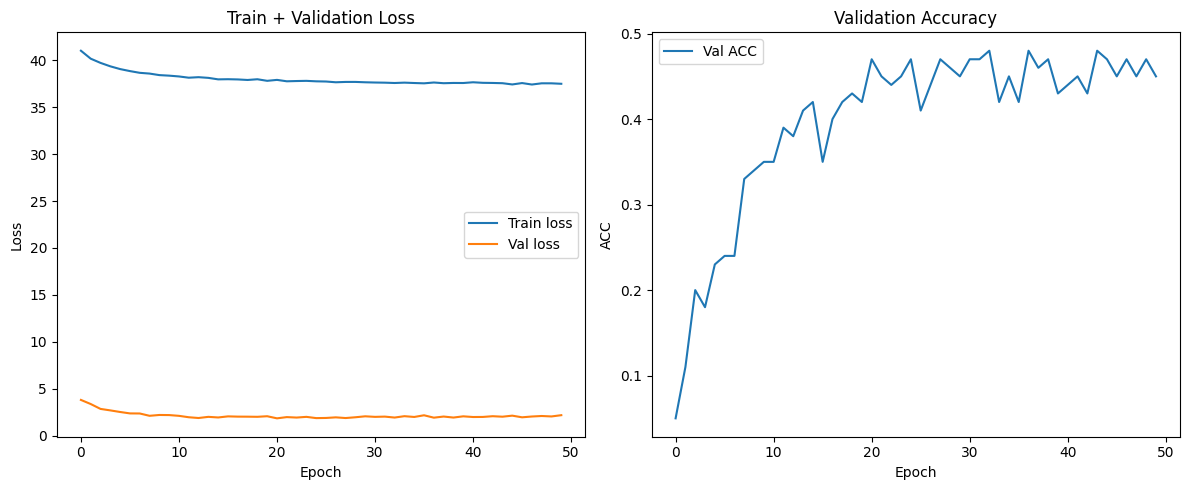

In [274]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

axes[0].plot(np.arange(EPOCHS), losses_train, label="Train loss")
cpu_losses_val = [tensor.cpu() for tensor in losses_val]
axes[0].plot(np.arange(EPOCHS), cpu_losses_val, label="Val loss")
axes[0].set_title("Train + Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(np.arange(EPOCHS), accs_val, label="Val ACC")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ACC")
axes[1].legend()

plt.tight_layout()
plt.show()

# Stopping point

# Save it

#### Save the weights

In [275]:
torch.save(base_model.state_dict(), getWeightsPath())

#### Save the model

In [276]:
torch.save(base_model, getModelPath())